# SNR Distribution: O1-O4b Injections vs. Real Detections

## Context


The goal is to compare the SNR distribution of **simulated injections** (O1-O4b) with the
SNR distribution of **real detections** (O1-O4b), split by source classification (BBH, NSBH, BNS).

### What are injections?
Injections are **artificial gravitational-wave signals** injected into real detector noise
to characterize the sensitivity of the search pipelines. They are NOT real astrophysical events.
By injecting millions of simulated signals and checking which ones are recovered, we can estimate
P(detection | signal parameters) — i.e., the probability that a signal with given masses, spins,
and distance would be detected.

### Why do we need injections?
When we observe ~289 real events, we cannot directly infer the true astrophysical population
because the detector is **biased**: it detects massive BBH more easily than faint BNS.
Injections allow us to correct for this selection bias.

### What is SNR?
The **Signal-to-Noise Ratio (SNR)** measures how loud a gravitational-wave signal is
relative to the detector noise. A typical detection threshold is SNR ~ 8 for the network.
In practice:
- BBH mergers are detectable from SNR ~ 8
- BNS/NSBH mergers tend to require SNR ~ 10 due to additional pipeline cuts

### What is FAR?
The **False Alarm Rate (FAR)** measures how often a noise fluctuation would mimic a signal.
Amanda's pipeline uses a threshold of **FAR < 1/4 years** (= 0.25 per year),
meaning we only keep injections that are recovered with very high confidence.

### Data source
- File: `mixture-semi_o1_o2-real_o3_o4a-cartesian_spins.hdf`
- Zenodo: [10.5281/zenodo.16740128](https://zenodo.org/records/16740128)
- O1+O2: semianalytic sensitivity estimates (no real injections available)
- O3+O4a: real injections processed by LVK search pipelines (GstLAL, MBTA, PyCBC, cWB)

### Source classification
We classify each injection based on **source-frame component masses**:
- **BNS** (Binary Neutron Star): m1 ≤ 3 M☉ and m2 ≤ 3 M☉
- **NSBH** (Neutron Star - Black Hole): m2 ≤ 3 M☉ and m1 > 3 M☉
- **BBH** (Binary Black Hole): m1 > 3 M☉ and m2 > 3 M☉

The 3 M☉ boundary is the conventional maximum neutron star mass.

## Step 1: Load the injection file

The HDF file contains a single dataset `events` with one row per injection.
We extract:
- `mass1_source`, `mass2_source`: source-frame component masses [solar masses]
- `estimated_optimal_snr_net`: network optimal SNR estimated from reference PSDs
- `weights`: mixture model weights (needed for correct importance sampling)
- `*_far`: False Alarm Rate from each search pipeline [1/year]

Note: `estimated_optimal_snr_net` is a **theoretical** SNR computed from the detector's
Power Spectral Density (PSD). It is available for all injections (O1-O4b).
The actual observed SNR from search pipelines is only available for O3+O4a.

In [16]:
%%bash
# Download GWTC-5.0 cumulative sensitivity injection file (O1-O4b, ~1.1 GB) if not already present
# https://zenodo.org/records/19500052, Essick et al. 2025, arXiv:2508.10638

OUTFILE="../../data/injections/mixture-semi_o1_o2-real_o3_o4a_o4b-cartesian_spins_20260410130052UTC-clipped.hdf"
URL="https://zenodo.org/records/19500052/files/mixture-semi_o1_o2-real_o3_o4a_o4b-cartesian_spins_20260410130052UTC-clipped.hdf?download=1"

mkdir -p ../../data/injections

if [ -f "$OUTFILE" ]; then
    echo "File already exists, skipping download."
else
    echo "Downloading GWTC-5.0 injection file (O1-O4b, ~1.1 GB)..."
    curl -L ,progress-bar -o "$OUTFILE" "$URL"
    echo "Done!"
fi


File already exists, skipping download.


## Setup: logging, plot style, output directory


In [17]:
import logging
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# ============================================================================
# Logging / warning configuration
# ============================================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore", message="No LaTeX-compatible font")
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# ============================================================================
# Matplotlib style , same convention as scripts/paper_plots/*.py
# ============================================================================
USE_LATEX = True if shutil.which("latex") is not None else False

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "text.usetex": USE_LATEX,
        "font.size": 12,
        "legend.fontsize": 14,
        "axes.labelsize": 12,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "savefig.dpi": 300,
    }
)

# ============================================================================
# Output directory
# ============================================================================
OUTDIR = Path("../outputs/SNR_FAR_detection_criterion")
OUTDIR.mkdir(parents=True, exist_ok=True)


SOURCE_NOTEBOOK = "scripts/notebooks/SNR_FAR_detection_criterion.ipynb"


def _figure_metadata(ext: str) -> dict:
    """Format-appropriate provenance metadata , PNG accepts arbitrary
    keys, but PDF and SVG only accept a fixed, format-specific key set
    (mismatched keys raise/warn), so this can't be one dict for all three."""
    if ext == "pdf":
        return {"Creator": SOURCE_NOTEBOOK}
    if ext == "svg":
        return {"Source": SOURCE_NOTEBOOK, "Creator": "matplotlib"}
    return {"Source": SOURCE_NOTEBOOK, "Software": "matplotlib"}


def save_figure(fig, basename: str, dpi: int = 200) -> None:
    """Save *fig* as both PNG and PDF under OUTDIR.

    Embeds the generating notebook's path in the file metadata so that,
    with many scripts and notebooks all writing into the same output
    folder, a figure's provenance can still be read off the file itself
    (e.g. via `exiftool` or PIL), not just guessed from its name.
    """
    for ext in ("png", "pdf"):
        out_path = OUTDIR / f"{basename}.{ext}"
        fig.savefig(
            out_path, dpi=dpi, bbox_inches="tight", metadata=_figure_metadata(ext)
        )
        logger.info("Saved ==> %s", out_path.resolve())


# ============================================================================
# FAR floor handling
# ============================================================================
# No display clipping: every real FAR value is plotted as-is, down to the
# true minimum (~2.6e-107 among injections). FAR_FLOOR exists only to place
# the handful of *exact* FAR=0 real detections somewhere on a log axis
# (log(0) is undefined) , it is set below the true observed minimum, so it
# never competes with or truncates any genuine nonzero value.
FAR_FLOOR = 1e-110


def far_for_log_axis(values, floor=FAR_FLOOR):
    """Replace exact-zero FAR values with *floor* so they can be placed on
    a log axis; every nonzero value (however small) passes through unchanged."""
    values = np.asarray(values, dtype=float)
    out = values.copy()
    out[out <= 0] = floor
    return out

In [18]:
import h5py
import matplotlib.pyplot as plt

INJECTION_FILE = "../../data/injections/mixture-semi_o1_o2-real_o3_o4a_o4b-cartesian_spins_20260410130052UTC-clipped.hdf"

with h5py.File(INJECTION_FILE, "r") as f:
    # Source-frame masses [solar masses]
    mass1 = f["events"]["mass1_source"][:]
    mass2 = f["events"]["mass2_source"][:]

    # Optimal SNR estimated from reference PSDs
    # This is a theoretical upper bound on the actual observed SNR
    snr = f["events"]["estimated_optimal_snr_net"][:]
    snr_H = f["events"]["estimated_optimal_snr_H"][:]
    snr_L = f["events"]["estimated_optimal_snr_L"][:]
    snr_V = f["events"]["estimated_optimal_snr_V"][:]

    snr_semi = f["events"]["semianalytic_observed_phase_maximized_snr_net"][:]

    distance = f["events"]["luminosity_distance"][:]

    # Mixture model weights: correct for different injection rates across runs
    weights = f["events"]["weights"][:]

    # List of search pipelines that provided FAR values
    searches = f.attrs["searches"]

    # Minimum FAR across all pipelines [1/year]
    # An injection is 'detected' if at least one pipeline reports a low FAR
    far_sim = np.min([f["events"][f"{s}_far"][:] for s in searches], axis=0)


print(f"Total injections loaded : {len(snr):,}")
print(f"Search pipelines        : {list(searches)}")
print(f"SNR range               : {snr.min():.1f} - {snr.max():.1f}")
print(
    f"FAR range               : {far_sim[far_sim < np.inf].min():.2e} - {far_sim[far_sim < np.inf].max():.2e} /year"
)

Total injections loaded : 2,504,653
Search pipelines        : ['o3_cwb', 'o3_gstlal', 'o3_mbta', 'o3_pycbc_bbh', 'o3_pycbc_hyperbank', 'o4a_cwb-bbh', 'o4a_gstlal', 'o4a_mbta', 'o4a_pycbc', 'o4b_cwb-bbh', 'o4b_gstlal', 'o4b_mbta', 'o4b_pycbc']
SNR range               : 4.0 - 1006.9
FAR range               : 2.59e-107 - 1.00e+03 /year


## Step 2: Apply the FAR threshold

Amanda's pipeline uses a threshold of **FAR < 1/4 years = 0.25 per year**.
This means we only keep injections that are so significant that a false alarm
would occur at most once every 4 years by chance.

Note: FAR is expressed in **events per year**:
- FAR = 0.25 /year → 1 false alarm every **4 years** (Amanda's threshold)
- FAR = 1.0 /year → 1 false alarm every **1 year**

In [19]:
# FAR threshold: 1 false alarm per 4 years = 0.25 per year
FAR_THRESHOLD = 0.25  # [1/year]

sel = far_sim < FAR_THRESHOLD

print(f"Injections passing FAR < {FAR_THRESHOLD}/year : {sel.sum():,} / {len(sel):,}")
print(f"Fraction kept : {sel.mean():.1%}")

Injections passing FAR < 0.25/year : 1,108,698 / 2,504,653
Fraction kept : 44.3%


## Step 3: Classify injections by source type

We classify each injection using the **source-frame component masses**.
The conventional boundary between neutron stars and black holes is **3 M☉**:

| Classification | m1 | m2 |
|---|---|---|
| BNS  | ≤ 3 M☉ | ≤ 3 M☉ |
| NSBH | > 3 M☉ | ≤ 3 M☉ |
| BBH  | > 3 M☉ | > 3 M☉ |

Note: by convention m1 ≥ m2 (primary is always the heavier object).

In [20]:
def classify(m1, m2, ns_mass_limit=2.5):
    """Classify a compact binary by source type based on component masses.

    Parameters
    ----------
    m1 : float
        Primary (heavier) mass in solar masses
    m2 : float
        Secondary (lighter) mass in solar masses
    ns_mass_limit : float
        Maximum neutron star mass in solar masses (default: 3.0)

    Returns
    -------
    str : 'BNS', 'NSBH', or 'BBH'
    """
    if m1 < ns_mass_limit and m2 < ns_mass_limit:
        return "BNS"
    elif m1 >= ns_mass_limit and m2 < ns_mass_limit:
        return "NSBH"
    else:
        return "BBH"


# Apply classification to all injections passing FAR threshold
labels = np.array([classify(m1, m2) for m1, m2 in zip(mass1[sel], mass2[sel])])
snr_sel = snr[sel]

for cat in ["BBH", "NSBH", "BNS"]:
    n = (labels == cat).sum()
    print(f"{cat:4s} : {n:7,} injections ({n / len(labels):.1%})")

# Full (unfiltered) classification, used by FAR-vs-SNR panels that plot
# every injection without pre-cutting to FAR < FAR_THRESHOLD, so the FAR
# distribution itself stays visible instead of already being cut at 0.25/yr.
labels_all = np.array([classify(m1, m2) for m1, m2 in zip(mass1, mass2)])

BBH  : 978,959 injections (88.3%)
NSBH :  64,227 injections (5.8%)
BNS  :  65,512 injections (5.9%)


## Step 4: Plot SNR distributions

We produce two panels:
- **Left**: histogram of SNR (normalized to proportion, so all categories are comparable)
- **Right**: cumulative distribution of SNR (same format as Leo's plot of real detections)

The vertical dashed line at SNR = 8 marks the typical detection threshold for BBH.

### What to expect
- BBH should start being detected at SNR ~ 8
- BNS/NSBH should start at SNR ~ 10 in the real detection plot
- If the injection distributions match the real detections → the sensitivity model is valid

2026-08-19 14:58:52  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_injections_cumulative.png
2026-08-19 14:58:55  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_injections_cumulative.pdf


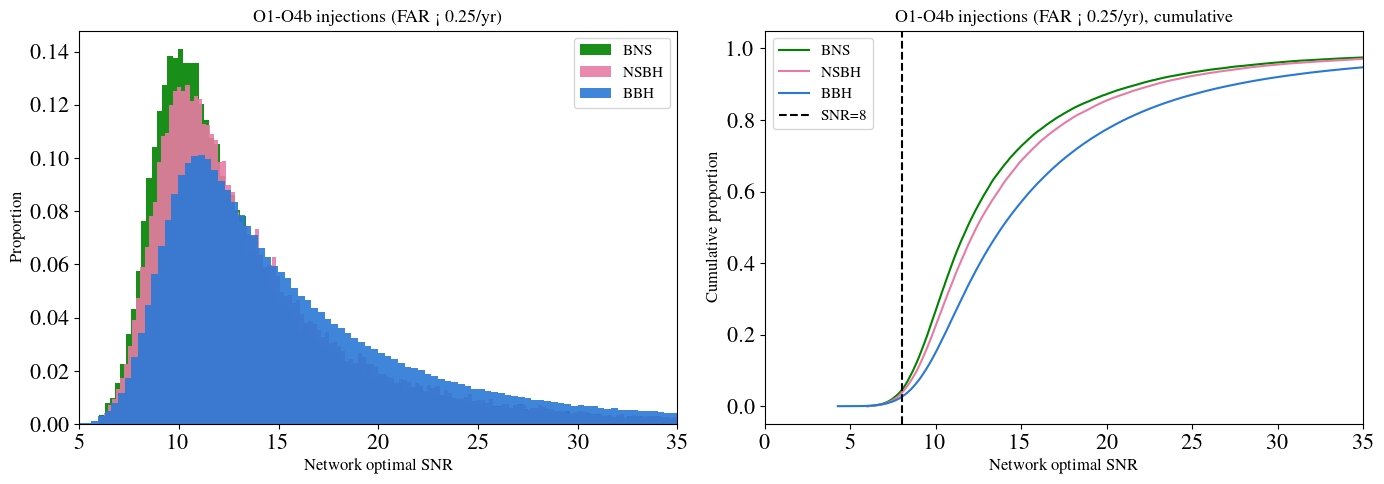

Plot saved to SNR_injections_cumulative.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    "BBH": "#2a78d6",
    "NSBH": "#e87ba4",
    "BNS": "#008300",
}  # validated categorical palette (CVD-safe, dataviz skill)

for cat in ["BNS", "NSBH", "BBH"]:
    mask = labels == cat
    snr_cat = np.sort(snr_sel[mask])

    # Left panel: normalized histogram
    # density=True normalizes so that the integral = 1
    # This allows comparison between categories despite very different counts
    axes[0].hist(
        snr_cat, bins=3000, density=True, alpha=0.9, color=colors[cat], label=cat
    )

    # Right panel: empirical cumulative distribution function (ECDF)
    # x-axis: SNR values sorted in ascending order
    # y-axis: fraction of events with SNR <= x
    axes[1].plot(snr_cat, np.linspace(0, 1, len(snr_cat)), color=colors[cat], label=cat)

# Reference line at SNR = 8 (typical BBH detection threshold)
axes[1].axvline(8, color="black", linestyle="--", label="SNR=8")

# Formatting
axes[0].set_xlabel("Network optimal SNR", fontsize=12)
axes[0].set_ylabel("Proportion", fontsize=12)
axes[0].set_title(f"O1-O4b injections (FAR < {FAR_THRESHOLD}/yr)", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim(5, 35)

axes[1].set_xlabel("Network optimal SNR", fontsize=12)
axes[1].set_ylabel("Cumulative proportion", fontsize=12)
axes[1].set_title(
    f"O1-O4b injections (FAR < {FAR_THRESHOLD}/yr), cumulative", fontsize=13
)
axes[1].set_xlim(0, 35)
axes[1].legend(fontsize=11)

plt.tight_layout()
save_figure(fig, "SNR_injections_cumulative")
plt.show()
print("Plot saved to SNR_injections_cumulative.png")

2026-08-19 14:58:58  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR.png
2026-08-19 14:59:00  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR.pdf
/var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/ipykernel_19656/4282139319.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


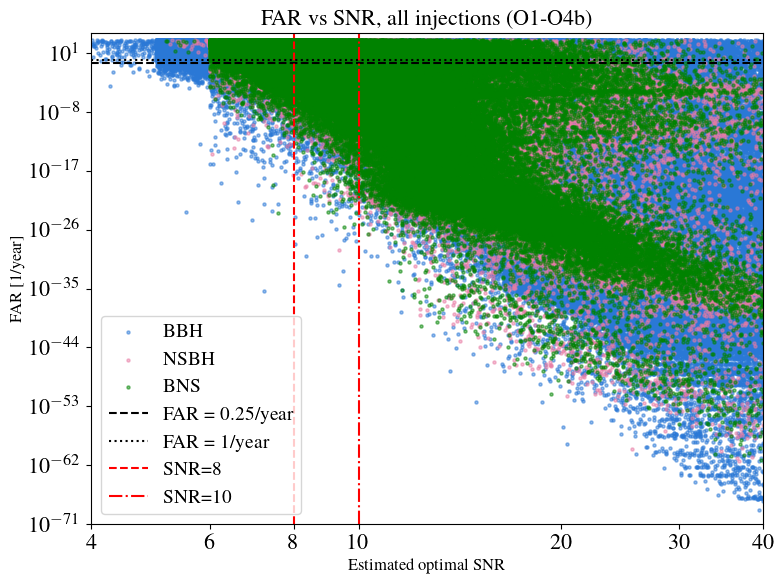

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {
    "BBH": "#2a78d6",
    "NSBH": "#e87ba4",
    "BNS": "#008300",
}  # validated categorical palette (CVD-safe, dataviz skill)

for cat in ["BBH", "NSBH", "BNS"]:
    mask = labels_all == cat

    ax.scatter(
        snr[mask],
        far_for_log_axis(far_sim[mask]),
        alpha=0.5,
        s=5,
        color=colors[cat],
        label=cat,
        rasterized=True,  # ~2.5M points -- vector paths would bloat the PDF to tens of MB
    )

ax.axhline(0.25, color="black", linestyle="--", label="FAR = 0.25/year")
ax.axhline(1.0, color="black", linestyle=":", label="FAR = 1/year")
ax.set_xlabel("Estimated optimal SNR")
ax.set_ylabel("FAR [1/year]")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylim(1e-71, 1e4)
ax.set_xlim(4, 40)
ax.set_xticks([4, 6, 8, 10, 20, 30, 40])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.minorticks_off()
ax.axvline(8, color="red", linestyle="--", label="SNR=8")
ax.axvline(10, color="red", linestyle="-.", label="SNR=10")
ax.set_title("FAR vs SNR, all injections (O1-O4b)")
save_figure(fig, "SNR_FAR")
ax.legend()
plt.tight_layout()
plt.show()

## Notes and caveats

### On the SNR used here
We use `estimated_optimal_snr_net`, which is a **theoretical upper bound** on the actual
observed SNR. It is computed from reference PSDs and does not account for:
- Non-Gaussian noise fluctuations
- Pipeline-specific cuts (chi-squared tests, coherence tests, etc.)
- The actual matched-filter output

This is why some BNS injections appear at SNR < 8, whereas real BNS detections
are typically found at SNR ~ 10+. The real observed SNR from pipelines
(e.g., `o4a_gstlal_ranking_statistic`) is only available for O3+O4a injections.

### On the population weighting
This plot does **not** apply the Fullpop-4 population weights (`weights` column).
To reproduce Amanda's weighted plot, one would need to resample the injections
according to these weights, as done by `gwpopulation_pipe`.

### On the number of injections
The large number of injections (~1.7M total) is by design: population inference
requires N_eff >> N_detected to get precise estimates. With ~289 real detections,
we need at least ~10,000 effective injection samples.

## OBserved data from public GWTC-5.0 catalog release : from O1 to O4b

**Source:** GWOSC Event Portal, filtered to `catalog=GWTC-5.0`:
<https://gwosc.org/eventapi/html/GWTC-5.0/> (CSV export via the "Download table as: ASCII - CSV" button; GWTC-5.0 covers O1 through the end of O4b, no O4c events are in any reviewed catalog release yet).


In [23]:
from astropy.table import Table

In [24]:
# ── Load ──────────────────────────────────────────────────────────────────────
table = Table.read("../../data/raw/GWTC-5.0_from_O1-to-O4b.csv", format="ascii.csv")
# Garder seulement les événements avec masses connues

print("Table length before filtering:", len(table))

table = table[~table["mass_1_source"].mask & ~table["mass_2_source"].mask]

print("Table length after mass filtering:", len(table))

# Some early O1/O2 events (e.g. GW150914) have no FAR value in this export
# (masked, not measured-as-zero). np.array() on a masked column silently
# fills those with 0.0, which would otherwise be misread as an extremely
# significant near-zero FAR by far_for_log_axis. Drop them explicitly.
n_missing_far = int(table["far"].mask.sum())
print(f"Events with missing FAR (dropped): {n_missing_far}")
table = table[~table["far"].mask]
print("Table length after FAR filtering:", len(table))

# No FAR < FAR_THRESHOLD cut here: this `table` is shared by every cell
# below, including fig:far-vs-snr, whose whole point is to show real
# candidates spread across both the FAR=1/yr and FAR=0.25/yr reference
# lines. Pre-cutting here would put every real point under the 0.25 line
# and make that comparison vacuous. The one figure that does need a
# FAR<0.25 real sample (fig:snr-real-vs-inj, to match the injection cut)
# builds its own locally-filtered copy instead of overwriting this one.

Table length before filtering: 391
Table length after mass filtering: 282
Events with missing FAR (dropped): 10
Table length after FAR filtering: 272


In [25]:
# ── Classification from masses ────────────────────────────────────────────────
NS_MAX = 2.5
classification = []
for row in table:
    m1 = row["mass_1_source"]
    m2 = row["mass_2_source"]
    if m1 < NS_MAX and m2 < NS_MAX:
        classification.append("BNS")
    elif m1 >= NS_MAX and m2 < NS_MAX:
        classification.append("NSBH")
    else:
        classification.append("BBH")
table["classification"] = classification

Real       : 4.5 → 78.6
Injections : 4.3 → 1006.9


2026-08-19 14:59:21  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_real_vs_injections.png
2026-08-19 14:59:22  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_real_vs_injections.pdf


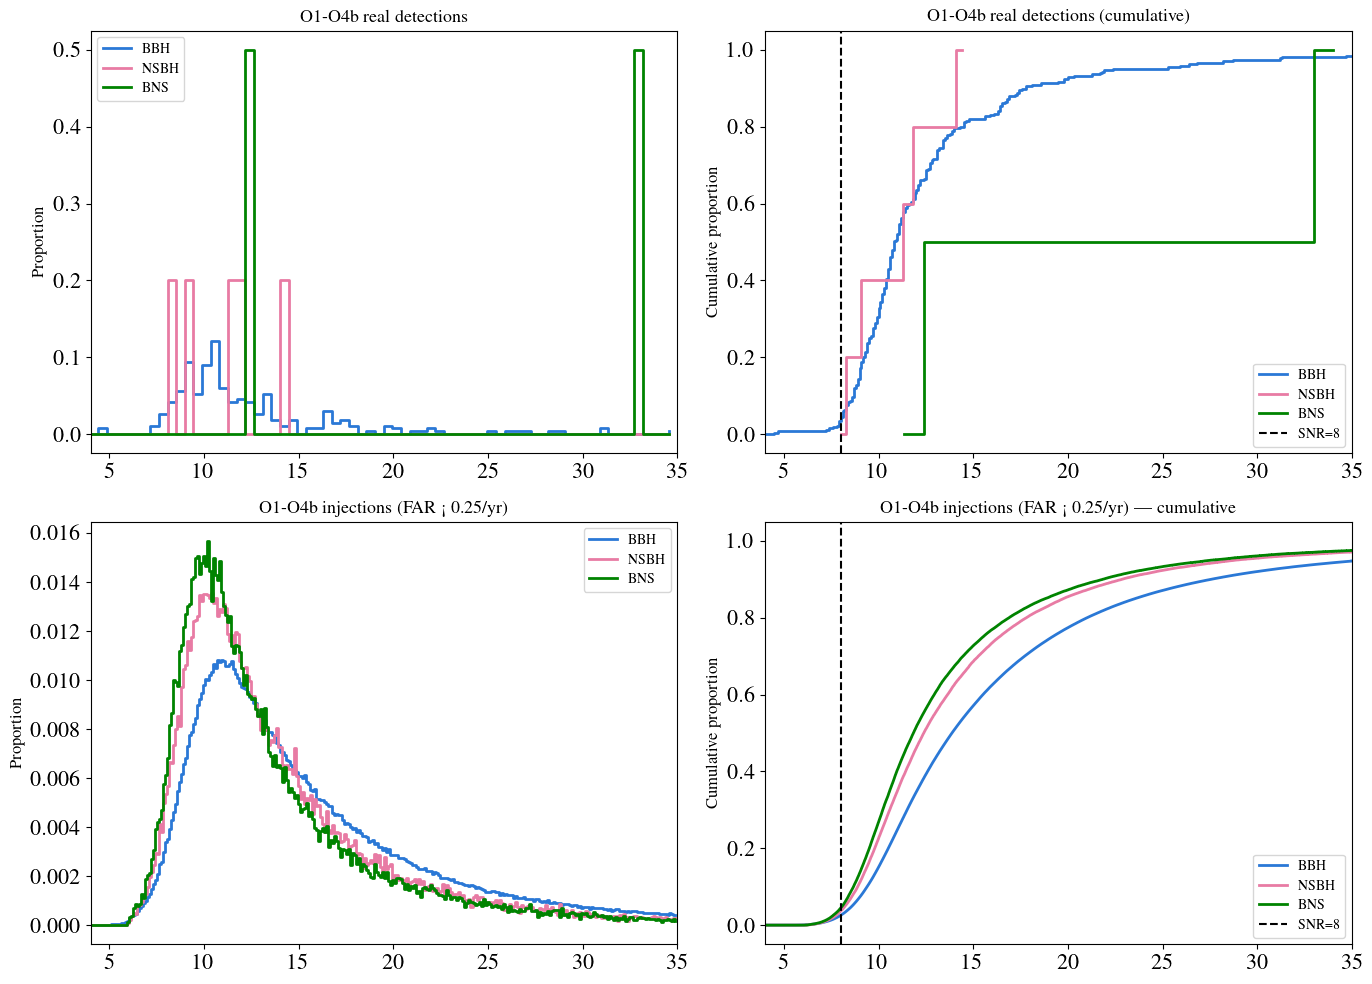

In [26]:
from scipy.stats import ecdf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {
    "BBH": "#2a78d6",
    "NSBH": "#e87ba4",
    "BNS": "#008300",
}  # validated categorical palette (CVD-safe, dataviz skill)
# Real detections: fewer events so fewer bins

# Real detections
snr_real_all = np.array(table["network_matched_filter_snr"])
snr_min_real = snr_real_all.min()
snr_max_real = snr_real_all.max()

# Injections
snr_min_inj = snr_sel.min()
snr_max_inj = snr_sel.max()

print(f"Real       : {snr_min_real:.1f} → {snr_max_real:.1f}")
print(f"Injections : {snr_min_inj:.1f} → {snr_max_inj:.1f}")

# Bins with margin on both sides
snr_bins_real = np.linspace(snr_min_real - 1, 35, 70)
snr_bins_inj = np.linspace(snr_min_inj - 1, 35, 300)


for cat in ["BBH", "NSBH", "BNS"]:
    # ── Row 0: Real detections ─────────────────────────────────────────────
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])

    counts, edges = np.histogram(snr_real, bins=snr_bins_real)
    axes[0, 0].step(
        edges[:-1],
        counts / len(snr_real),
        where="post",
        color=colors[cat],
        linewidth=2,
        label=cat,
    )

    res = ecdf(snr_real)
    res.cdf.plot(ax=axes[0, 1], color=colors[cat], linewidth=2, label=cat)

    # ── Row 1: Injections ──────────────────────────────────────────────────
    mask_inj = labels == cat
    snr_inj = snr_sel[mask_inj]

    counts_inj, edges_inj = np.histogram(snr_inj, bins=snr_bins_inj)
    axes[1, 0].step(
        edges_inj[:-1],
        counts_inj / len(snr_inj),
        where="post",
        color=colors[cat],
        linewidth=2,
        label=cat,
    )

    res_inj = ecdf(snr_inj)
    res_inj.cdf.plot(ax=axes[1, 1], color=colors[cat], linewidth=2, label=cat)

# Reference lines
for ax in [axes[0, 1], axes[1, 1]]:
    ax.axvline(8, color="black", linestyle="--", linewidth=1.5, label="SNR=8")

# Titles
axes[0, 0].set_title("O1-O4b real detections", fontsize=13)
axes[0, 1].set_title("O1-O4b real detections (cumulative)", fontsize=13)
axes[1, 0].set_title(f"O1-O4b injections (FAR < {FAR_THRESHOLD}/yr)", fontsize=13)
axes[1, 1].set_title(
    f"O1-O4b injections (FAR < {FAR_THRESHOLD}/yr) — cumulative", fontsize=13
)


# Formatting
for ax in axes.flatten():
    ax.legend(fontsize=10)

axes[0, 0].set_ylabel("Proportion", fontsize=12)
axes[0, 1].set_ylabel("Cumulative proportion", fontsize=12)
axes[1, 0].set_ylabel("Proportion", fontsize=12)
axes[1, 1].set_ylabel("Cumulative proportion", fontsize=12)


# xlim adapted to each row
axes[0, 0].set_xlim(4, 35)
axes[0, 1].set_xlim(4, 35)
axes[1, 0].set_xlim(4, 35)
axes[1, 1].set_xlim(4, 35)

plt.tight_layout()
save_figure(fig, "SNR_real_vs_injections")
plt.show()

/var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/ipykernel_19656/1892334888.py:56: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/ipykernel_19656/3880335876.py:74: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
2026-08-19 14:59:49  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_vs_FAR_injections-vs-real.png
2026-08-19 15:00:14  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_vs_FAR_injections-vs-real.pdf
/Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


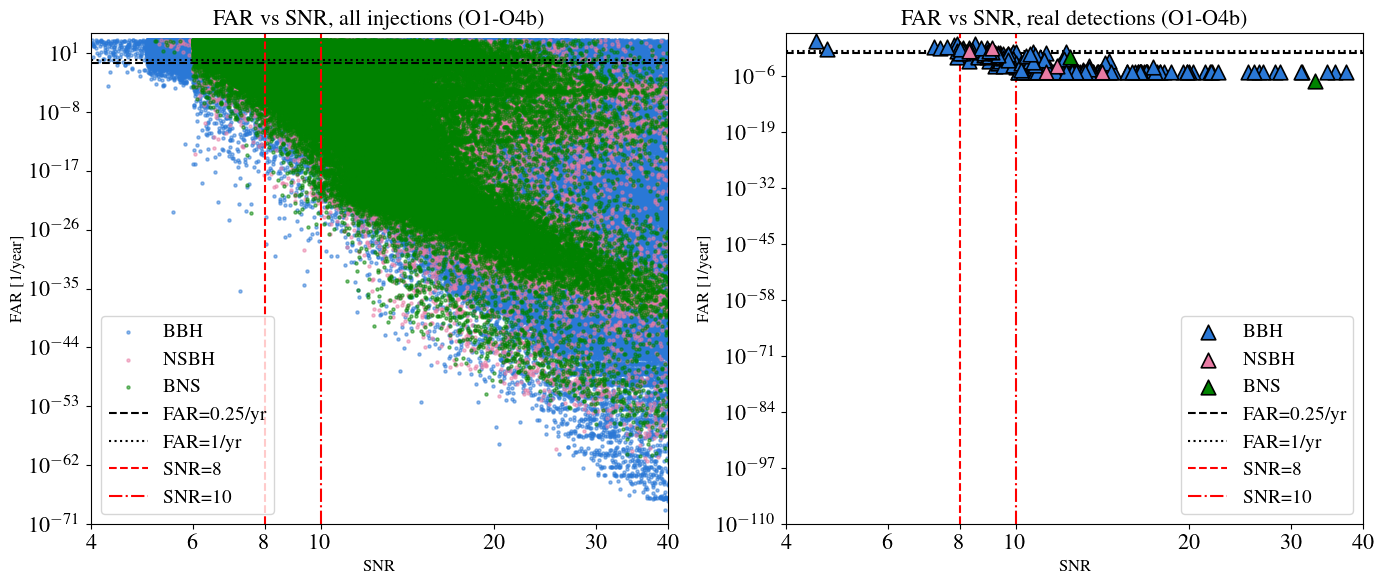

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Injections, full sample, not pre-cut to FAR < FAR_THRESHOLD
for cat in ["BBH", "NSBH", "BNS"]:
    mask = labels_all == cat
    axes[0].scatter(
        snr[mask],
        far_for_log_axis(far_sim[mask]),
        alpha=0.5,
        s=5,
        color=colors[cat],
        label=cat,
        rasterized=True,  # ~2.5M points -- vector paths would bloat the PDF to tens of MB
    )

axes[0].set_title("FAR vs SNR, all injections (O1-O4b)")

# Real detections
for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])
    far_real = far_for_log_axis(np.array(table[mask_real]["far"]))
    axes[1].scatter(
        snr_real,
        far_real,
        alpha=1.0,
        s=110,
        color=colors[cat],
        marker="^",
        edgecolors="black",
        linewidth=1.2,
        label=cat,
        zorder=6,
    )

axes[1].set_title("FAR vs SNR, real detections (O1-O4b)")

for ax in axes:
    ax.axhline(0.25, color="black", linestyle="--", label="FAR=0.25/yr")
    ax.axhline(1.0, color="black", linestyle=":", label="FAR=1/yr")
    ax.axvline(8, color="red", linestyle="--", label="SNR=8")
    ax.axvline(10, color="red", linestyle="-.", label="SNR=10")
    ax.set_xlabel("SNR")
    ax.set_ylabel("FAR [1/year]")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlim(4, 40)
    ax.set_xticks([4, 6, 8, 10, 20, 30, 40])
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.minorticks_off()
    ax.legend()

axes[0].set_ylim(1e-71, 1e4)  # All injections panel, tighter floor
axes[1].set_ylim(FAR_FLOOR, 1e4)  # Real detections panel, unaffected

plt.tight_layout()
save_figure(fig, "SNR_vs_FAR_injections-vs-real")
plt.show()

## Step 5: Combined comparison figure (SNR ECDF + FAR vs SNR)

Two panels, real detections and found injections overlaid on the same axes
(not side by side), so the reversal in ordering between the two datasets is
visible at a glance:

- **(a)** SNR cumulative distributions, real detections (solid) vs. found
  injections (dashed), one colour per class. ECDF, not a KDE: the real BNS/NSBH
  samples are only ~2/~5 events, too few for a kernel density estimate to be
  meaningful.
- **(b)** FAR vs. SNR, shows that no single SNR threshold reproduces the
  FAR < 0.25/yr selection used by the actual pipelines. Raw scatter, not a
  density estimate, since the point is exactly the *spread* at fixed SNR.


/var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/ipykernel_19656/547059970.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/4g/cl8xxwd519vfllyyytyd76n0jxkd3q/T/ipykernel_19656/3880335876.py:74: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
2026-08-19 15:00:46  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR_real_vs_injections.png
2026-08-19 15:00:55  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR_real_vs_injections.pdf


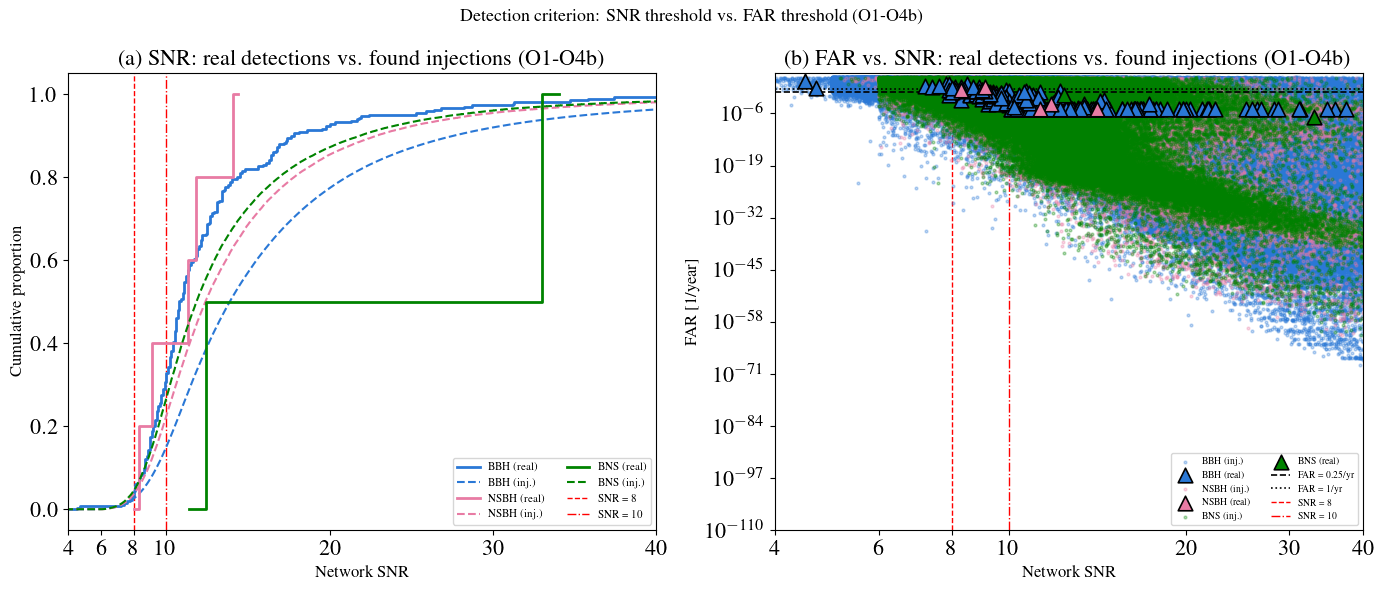

In [28]:
# ── Combined comparison: SNR (ECDF) and FAR vs SNR, real vs injections ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Panel (a): SNR cumulative distributions, overlaid ---------------------
for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])
    res_real = ecdf(snr_real)
    res_real.cdf.plot(
        ax=axes[0],
        color=colors[cat],
        linewidth=2,
        linestyle="-",
        label=f"{cat} (real)",
    )

    mask_inj = labels == cat
    snr_inj = snr_sel[mask_inj]
    res_inj = ecdf(snr_inj)
    res_inj.cdf.plot(
        ax=axes[0],
        color=colors[cat],
        linewidth=1.5,
        linestyle="--",
        label=f"{cat} (inj.)",
    )

axes[0].axvline(8, color="red", linestyle="--", linewidth=1, label="SNR = 8", zorder=0)
axes[0].axvline(
    10, color="red", linestyle="-.", linewidth=1, label="SNR = 10", zorder=0
)
axes[0].set_xlim(4, 40)
axes[0].set_xticks([4, 6, 8, 10, 20, 30, 40])
axes[0].set_xlabel("Network SNR")
axes[0].set_ylabel("Cumulative proportion")
axes[0].set_title("(a) SNR: real detections vs. found injections (O1-O4b)")
axes[0].legend(fontsize=8, ncol=2)

# -- Panel (b): FAR vs SNR, overlaid, all injections, not pre-cut ---------
# FAR_FLOOR is defined once in the setup cell (only handles exact FAR=0);
# no local override here, so every real nonzero value is shown as-is.

for cat in ["BBH", "NSBH", "BNS"]:
    mask_inj = labels_all == cat
    far_inj = far_for_log_axis(far_sim[mask_inj])
    axes[1].scatter(
        snr[mask_inj],
        far_inj,
        alpha=0.3,
        s=4,
        color=colors[cat],
        marker="o",
        label=f"{cat} (inj.)",
        rasterized=True,  # ~2.5M points -- vector paths would bloat the PDF to tens of MB
    )

    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])
    far_real = far_for_log_axis(np.array(table[mask_real]["far"]))
    axes[1].scatter(
        snr_real,
        far_real,
        alpha=1.0,
        s=110,
        color=colors[cat],
        marker="^",
        edgecolors="black",
        linewidth=1.2,
        label=f"{cat} (real)",
        zorder=6,
    )

axes[1].axhline(
    0.25, color="black", linestyle="--", linewidth=1.2, label="FAR = 0.25/yr"
)
axes[1].axhline(1.0, color="black", linestyle=":", linewidth=1.2, label="FAR = 1/yr")
axes[1].axvline(8, color="red", linestyle="--", linewidth=1, label="SNR = 8", zorder=0)
axes[1].axvline(
    10, color="red", linestyle="-.", linewidth=1, label="SNR = 10", zorder=0
)
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_xlim(4, 40)
axes[1].set_xticks([4, 6, 8, 10, 20, 30, 40])
axes[1].xaxis.set_major_formatter(ScalarFormatter())
axes[1].minorticks_off()
axes[1].set_ylim(FAR_FLOOR, 1e4)
axes[1].set_xlabel("Network SNR")
axes[1].set_ylabel("FAR [1/year]")
axes[1].set_title("(b) FAR vs. SNR: real detections vs. found injections (O1-O4b)")
axes[1].legend(fontsize=7, ncol=2)

fig.suptitle(
    "Detection criterion: SNR threshold vs. FAR threshold (O1-O4b)", fontsize=13
)
plt.tight_layout()
save_figure(fig, "SNR_FAR_real_vs_injections")
plt.show()

## Step 5: FAR vs. SNR,  injections vs. real detections (separate panels)

Two side-by-side panels, injections and real detections plotted separately (not
overlaid), each showing FAR vs. SNR on log-log axes with:

- Vertical dashed lines at SNR = 8 and SNR = 10.
- A horizontal dashed line at FAR = 0.25/yr (the significance threshold used
  throughout this analysis).

The point: for real detections, every BNS/NSBH candidate below the FAR = 0.25/yr
line sits to the right of SNR = 10, a single SNR threshold at 8 (the BBH value)
would miss this, motivating the discussion of a mass-dependent SNR-FAR mapping.


2026-08-19 15:01:05  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR_injections_vs_real_separate.png
2026-08-19 15:01:08  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_FAR_injections_vs_real_separate.pdf


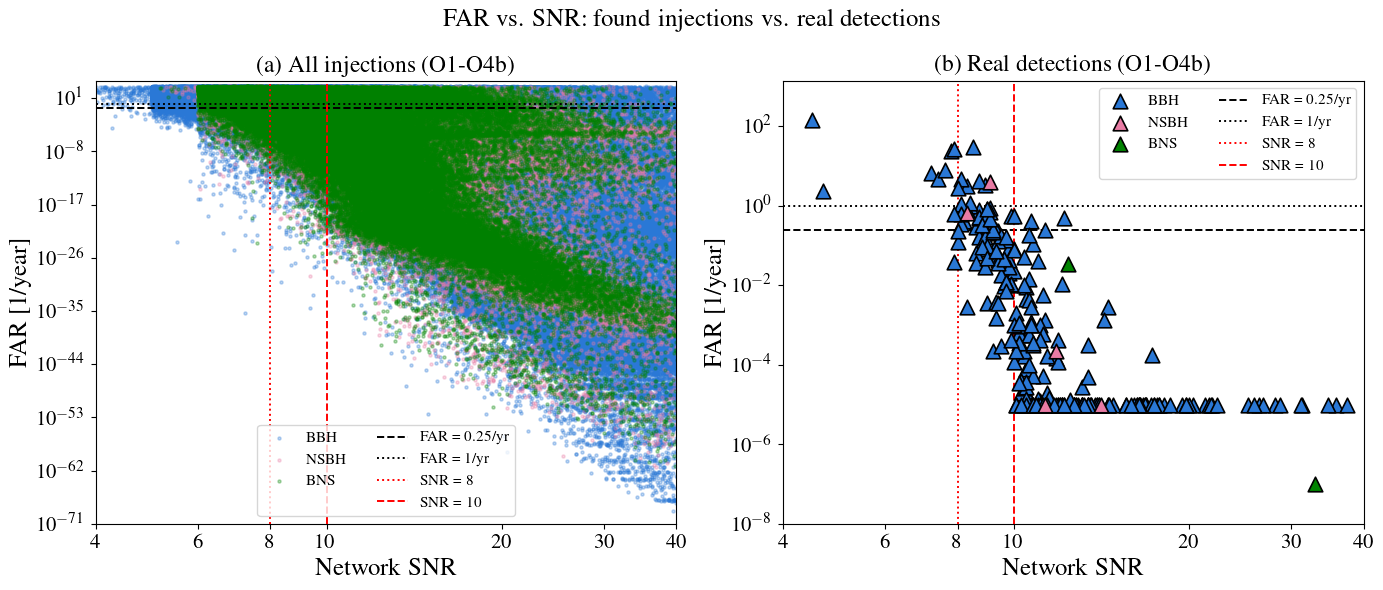

In [29]:
# ── FAR vs SNR: injections and real detections, separate panels ────────────
# Two scatter panels, each with its OWN y-axis fitted to its own data --
# not shared: injections (1.1M points) genuinely span down to ~1e-107,
# but the 282 real detections don't need that same 110-decade range, and
# forcing them to share it just squeezes the real panel into a corner.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# -- Panel (a): injections ---------------------------------------------------
ax = axes[0]
for cat in ["BBH", "NSBH", "BNS"]:
    mask_inj = labels_all == cat
    far_inj = far_for_log_axis(far_sim[mask_inj])
    ax.scatter(
        snr[mask_inj],
        far_inj,
        alpha=0.3,
        s=5,
        color=colors[cat],
        label=cat,
        rasterized=True,  # ~2.5M points -- vector paths would bloat the PDF to tens of MB
    )
ax.set_ylim(1e-71, 1e4)
ax.set_ylabel("FAR [1/year]", fontsize=18)
ax.set_title("(a) All injections (O1-O4b)", fontsize=17)

# -- Panel (b): real detections, own floor/range, fit to its own data -----
ax = axes[1]
real_far_by_cat = {}
for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table["classification"]) == cat
    real_far_by_cat[cat] = np.array(table[mask_real]["far"])

real_far_nonzero = np.concatenate(
    [v[v > 0] for v in real_far_by_cat.values() if (v > 0).any()]
)
REAL_FAR_FLOOR = real_far_nonzero.min() / 10  # one decade below the smallest
# measured nonzero real FAR
REAL_FAR_MAX = real_far_nonzero.max() * 10

for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])
    far_real = far_for_log_axis(real_far_by_cat[cat], floor=REAL_FAR_FLOOR)
    ax.scatter(
        snr_real,
        far_real,
        alpha=1.0,
        s=110,
        color=colors[cat],
        marker="^",
        edgecolors="black",
        linewidth=1.2,
        label=cat,
        zorder=6,
    )
ax.set_ylim(REAL_FAR_FLOOR, REAL_FAR_MAX)
ax.set_ylabel("FAR [1/year]", fontsize=18)
ax.set_title("(b) Real detections (O1-O4b)", fontsize=17)

# -- Shared formatting: SNR=8/10 and FAR=0.25/yr reference lines ------------
# (styling only,  each axis keeps the y-range set above)
for ax in axes:
    ax.axhline(
        0.25,
        color="black",
        linestyle="--",
        linewidth=1.4,
        label="FAR = 0.25/yr",
        zorder=5,
    )
    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.4,
        label="FAR = 1/yr",
        zorder=5,
    )
    ax.axvline(8, color="red", linestyle=":", linewidth=1.4, label="SNR = 8", zorder=5)
    ax.axvline(
        10, color="red", linestyle="--", linewidth=1.4, label="SNR = 10", zorder=5
    )
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlim(4, 40)
    ax.set_xticks([4, 6, 8, 10, 20, 30, 40])
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.minorticks_off()
    ax.set_xlabel("Network SNR", fontsize=18)
    ax.tick_params(labelsize=15)

# Two-column legend: column 1 = source categories (BBH/NSBH/BNS), column 2
# = FAR/SNR reference lines, matplotlib fills legends column-major, so a
# blank filler entry pads the (shorter) category group to line the two
# groups up cleanly into separate columns instead of one bleeding into the
# other.
_blank = plt.Line2D([], [], color="none", label="")
for ax, loc in [(axes[0], "lower center"), (axes[1], "upper right")]:
    handles, labels = ax.get_legend_handles_labels()
    cat_handles, cat_labels = handles[:3], labels[:3]
    ref_handles, ref_labels = handles[3:], labels[3:]
    ax.legend(
        cat_handles + [_blank] + ref_handles,
        cat_labels + [""] + ref_labels,
        fontsize=11,
        ncol=2,
        loc=loc,
    )

fig.suptitle("FAR vs. SNR: found injections vs. real detections", fontsize=18)
plt.tight_layout()

# Align the FAR (y) and SNR (x) axis labels in the same column/row across
# both panels, must happen AFTER tight_layout(), which is what actually
# moves the subplots; aligning before it gets overwritten by the layout pass.
fig.align_ylabels(axes)
fig.align_xlabels(axes)

save_figure(fig, "SNR_FAR_injections_vs_real_separate")
plt.show()

Real events: 272 total -> 230 at FAR < 0.25/yr


2026-08-19 15:01:09  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_ECDF_injections_vs_real.png
2026-08-19 15:01:09  INFO      Saved ==> /Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/scripts/outputs/SNR_FAR_detection_criterion/SNR_ECDF_injections_vs_real.pdf


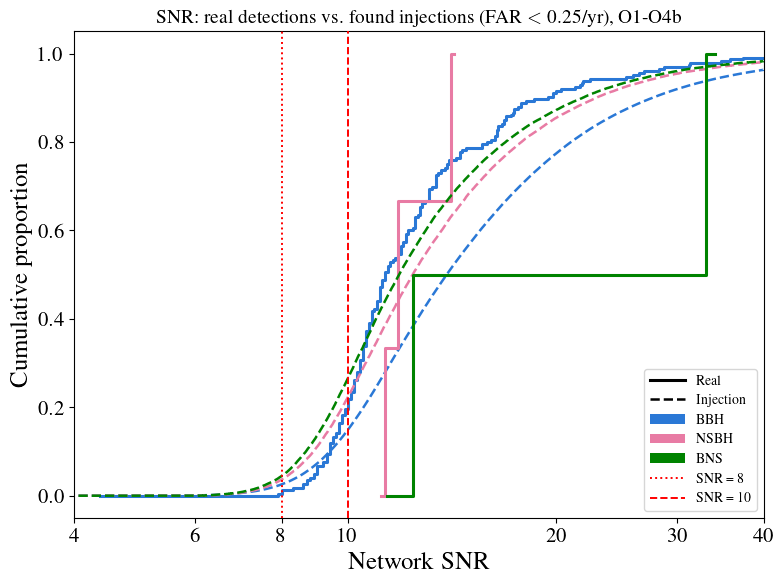

In [30]:
# ── SNR cumulative distribution (ECDF), standalone: injections vs. real ────
# One panel, per-category curves (BBH/NSBH/BNS), solid = real, dashed =
# injections -- found injections only (FAR < FAR_THRESHOLD), matching the
# FAR<0.25/yr floor quoted in the paper text for this figure.
#
# Real detections are also cut to FAR < FAR_THRESHOLD here, locally to
# this cell only (table_ecdf, not the shared `table`): fig:snr-real-vs-inj
# compares real and simulated SNR distributions at matched significance,
# unlike fig:far-vs-snr (cell above but one), which needs the full,
# uncut `table` to show candidates spanning both the FAR=1/yr and
# FAR=0.25/yr reference lines.
#
# Recomputed locally rather than reusing the global `labels`/`snr_sel`:
# the cell above (separate FAR-vs-SNR panels) does
# `handles, labels = ax.get_legend_handles_labels()`, which silently
# overwrites `labels` with a list of legend-label strings. Trusting the
# global here would make `labels == cat` compare a list to a string
# (always False), collapsing snr_sel[mask_inj] to the wrong shape.
from scipy.stats import ecdf

table_ecdf = table[np.array(table["far"]) < FAR_THRESHOLD]
print(
    f"Real events: {len(table)} total -> {len(table_ecdf)} at FAR < {FAR_THRESHOLD}/yr"
)

labels_ecdf = np.array([classify(m1, m2) for m1, m2 in zip(mass1[sel], mass2[sel])])
snr_sel_ecdf = snr[sel]

fig, ax = plt.subplots(figsize=(8, 6))

real_handles, real_labels, inj_handles, inj_labels = [], [], [], []
for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table_ecdf["classification"]) == cat
    snr_real_cat = np.array(table_ecdf[mask_real]["network_matched_filter_snr"])
    (h_real,) = ecdf(snr_real_cat).cdf.plot(
        ax=ax,
        color=colors[cat],
        linewidth=2.2,
        linestyle="-",
    )
    real_handles.append(h_real)
    real_labels.append(f"{cat} (real)")

    mask_inj = labels_ecdf == cat
    (h_inj,) = ecdf(snr_sel_ecdf[mask_inj]).cdf.plot(
        ax=ax,
        color=colors[cat],
        linewidth=1.8,
        linestyle="--",
    )
    inj_handles.append(h_inj)
    inj_labels.append(f"{cat} (inj.)")

ref_h8 = ax.axvline(8, color="red", linestyle=":", linewidth=1.4, zorder=5)
ref_h10 = ax.axvline(10, color="red", linestyle="--", linewidth=1.4, zorder=5)
ax.set_xscale("log")
ax.set_xlim(4, 40)
ax.set_xticks([4, 6, 8, 10, 20, 30, 40])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.minorticks_off()
ax.set_xlabel("Network SNR", fontsize=18)
ax.set_ylabel("Cumulative proportion", fontsize=18)
ax.tick_params(labelsize=15)
ax.set_title(
    rf"SNR: real detections vs. found injections (FAR $<$ {FAR_THRESHOLD}/yr), O1-O4b",
    fontsize=14,
)

# One combined legend, same pattern as bns_inspiral_range.py's
# plot_sensitivity_curves: linestyle carries the dataset (Real vs.
# Injection, generic black lines, not repeated per category), color
# carries the sub-population (BBH/NSBH/BNS), SNR reference lines appended
# at the end, all in a single box instead of separate ones.
linestyle_handles = [
    plt.Line2D([], [], color="black", linestyle="-", linewidth=2.2),
    plt.Line2D([], [], color="black", linestyle="--", linewidth=1.8),
]
color_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=colors[cat]) for cat in ["BBH", "NSBH", "BNS"]
]
ref_handles = [ref_h8, ref_h10]

ax.legend(
    linestyle_handles + color_handles + ref_handles,
    ["Real", "Injection", "BBH", "NSBH", "BNS", "SNR = 8", "SNR = 10"],
    fontsize=10,
    loc="lower right",
    handlelength=2.5,
)

plt.tight_layout()
save_figure(fig, "SNR_ECDF_injections_vs_real")
plt.show()